In [ ]:
from ase.io import read, write
from ase import units
import numpy as np
from imolcraft.crafter.ffxml import merge_xml
from imolcraft.trainer import DistanceTrainer
from imolcraft.calculator.distance import DistanceCalculator
from imolcraft.trainer.loss import loss_energy
from functools import partial

/Users/srak/apl/iMolCRAFT/DMFF/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")
Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


In [2]:
atoms_snli = read("SNLi.log")

In [3]:
merge_xml(["SN.xml", "Li.xml"], "merged.xml")

'xmlfiles/merged.xml'

In [4]:
calculator = DistanceCalculator(
    atoms_snli,
    1,
    "cn__Li",
    scan_idx=[[5,10]],
    directory="distance_scan",
    qmparams={
             "method": "wb97xd",
             "basis": "6-31g(d)",
             "opt": "modredundant",
             }
)

In [5]:
import glob

g16logs = glob.glob("distance_scan/*.log")

for i, g16log in enumerate(g16logs):
    atoms = read(g16log)
    distance = atoms.get_distance(5, 10)
    energy = atoms.get_potential_energy()/(units.kJ / units.mol)
    calculator.qm_scan[0]["distance_A"].append(distance)
    calculator.qm_scan[0]["energy_kjmol"].append(energy)
    calculator.qm_scan[0]["atoms"].append(atoms)

In [6]:
# calculator.qm_scan[0]でcalculator.qm_scan[0]["distance_A"]ベースでソート
# "distance_A"の値で全リストをソート
order = np.argsort(calculator.qm_scan[0]["distance_A"])
for key in calculator.qm_scan[0]:
	calculator.qm_scan[0][key] = [calculator.qm_scan[0][key][i] for i in order]

In [7]:
calculator.do_ffscan("xmlfiles/merged.xml")

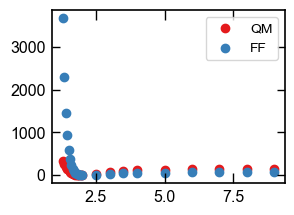

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.scatter(calculator.qm_scan[0]["distance_A"], np.array(calculator.qm_scan[0]["energy_kjmol"])-np.array(calculator.qm_scan[0]["energy_kjmol"]).min(), label="QM")

plt.scatter(calculator.ff_scan[0]["distance_A"], np.array(calculator.ff_scan[0]["energy_kjmol"])-np.array(calculator.ff_scan[0]["energy_kjmol"]).min(), label="FF")

plt.legend()

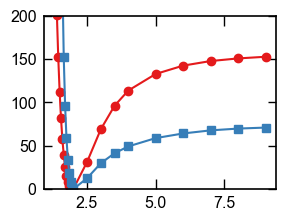

In [9]:
plt.ylim(0,200)
plt.plot(calculator.qm_scan[0]["distance_A"], np.array(calculator.qm_scan[0]["energy_kjmol"])-min(calculator.qm_scan[0]["energy_kjmol"]), marker="o")
plt.plot(calculator.ff_scan[0]["distance_A"], np.array(calculator.ff_scan[0]["energy_kjmol"])-min(calculator.ff_scan[0]["energy_kjmol"]), marker="s")

In [10]:
lossfn = partial(loss_energy, weight_scheme="boltzmann", zeropoint="qmmin")

In [ ]:
dtrainer = DistanceTrainer(ffxml_list=["SN.xml", "Li.xml"], 
                           nums_ffxml=[1,1], 
                           pdbfile="check.pdb", 
                           calculator=calculator,
                           loss_fn=lossfn,
                           opt_fftypes=["NonbondedForce/charges", "VirtualSite/weight"],
                           lr=0.0005)

In [39]:
dtrainer.ffparams

{'HarmonicBondForce': {'length': Array([0.1153, 0.1467, 0.1538, 0.1097], dtype=float64),
  'k': Array([746040.672, 247575.648, 194572.736, 314569.856], dtype=float64)},
 'HarmonicAngleForce': {'angle': Array([3.11680898, 1.94970731, 1.90956473, 1.91637152, 1.87762521],      dtype=float64),
  'k': Array([612.671488, 554.597568, 409.019472, 391.756288, 326.01728 ],      dtype=float64)},
 'PeriodicTorsionForce': {'proper_phase': Array([3.14159265, 3.14159265, 0.        , 0.        , 0.        ],      dtype=float64),
  'proper_k': Array([0.        , 0.        , 0.65084444, 0.65084444, 0.50208   ],      dtype=float64),
  'improper_phase': Array([], shape=(0,), dtype=float64),
  'improper_k': Array([], shape=(0,), dtype=float64)},
 'NonbondedForce': {'sigma': Array([0.32735182, 0.34789595, 0.33977095, 0.2600177 , 0.1       ,
         0.20259037], dtype=float64),
  'epsilon': Array([0.4594032, 0.6677664, 0.4510352, 0.0870272, 0.       , 0.0765672],      dtype=float64),
  'charges': Array([-0.

In [ ]:
from imolcraft.trainer.dmff_utils import neutralize

def grad_modify(grads):
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[12].set(0.0)
    ave_w = (grads["VirtualSite"]["weight"][1] + grads["VirtualSite"]["weight"][3]) / 2
    grads["VirtualSite"]["weight"] = grads["VirtualSite"]["weight"].at[0].set(-ave_w)
    grads["VirtualSite"]["weight"] = grads["VirtualSite"]["weight"].at[1].set(ave_w)
    grads["VirtualSite"]["weight"] = grads["VirtualSite"]["weight"].at[2].set(-ave_w)
    grads["VirtualSite"]["weight"] = grads["VirtualSite"]["weight"].at[3].set(ave_w)
    return grads

def ffparams_modify(ffparams):
    ffparams = neutralize(ffparams, dtrainer.natoms_list, nc=0.8, target_lists=[[0,1,2,3,4,5,6,7,8,9,10,11]], target_charges=[0.0])

    return ffparams

In [41]:
dtrainer.add_modifyfn("after_grad", grad_modify)
dtrainer.add_modifyfn("after_update", ffparams_modify)

In [42]:
# dtrainer.setup(trainer_checkpoint="train_state-12000.pkl")
dtrainer.setup()

In [43]:
dtrainer.ffparams

{'HarmonicBondForce': {'length': Array([0.1153, 0.1467, 0.1538, 0.1097], dtype=float64),
  'k': Array([746040.672, 247575.648, 194572.736, 314569.856], dtype=float64)},
 'HarmonicAngleForce': {'angle': Array([3.11680898, 1.94970731, 1.90956473, 1.91637152, 1.87762521],      dtype=float64),
  'k': Array([612.671488, 554.597568, 409.019472, 391.756288, 326.01728 ],      dtype=float64)},
 'PeriodicTorsionForce': {'proper_phase': Array([3.14159265, 3.14159265, 0.        , 0.        , 0.        ],      dtype=float64),
  'proper_k': Array([0.        , 0.        , 0.65084444, 0.65084444, 0.50208   ],      dtype=float64),
  'improper_phase': Array([], shape=(0,), dtype=float64),
  'improper_k': Array([], shape=(0,), dtype=float64)},
 'NonbondedForce': {'sigma': Array([0.32735182, 0.34789595, 0.33977095, 0.2600177 , 0.1       ,
         0.20259037], dtype=float64),
  'epsilon': Array([0.4594032, 0.6677664, 0.4510352, 0.0870272, 0.       , 0.0765672],      dtype=float64),
  'charges': Array([-0.

In [44]:
dtrainer.fit(steps=200, checkpoint_frequency=10)

Epoch 0 completed in 0.09 seconds.
Loss:  0.008733923549887158
Best Loss:  0.008733923549887158 at epoch  0
Epoch 1 completed in 0.08 seconds.
Loss:  0.008733923433968019
Best Loss:  0.008733923433968019 at epoch  1
Epoch 2 completed in 0.09 seconds.
Loss:  0.00873392331804717
Best Loss:  0.00873392331804717 at epoch  2
Epoch 3 completed in 0.09 seconds.
Loss:  0.00873392318192373
Best Loss:  0.00873392318192373 at epoch  3
Epoch 4 completed in 0.08 seconds.
Loss:  0.008733922989735243
Best Loss:  0.008733922989735243 at epoch  4
Epoch 5 completed in 0.08 seconds.
Loss:  0.008733922685793203
Best Loss:  0.008733922685793203 at epoch  5
Epoch 6 completed in 0.08 seconds.
Loss:  0.008733922184565755
Best Loss:  0.008733922184565755 at epoch  6
Epoch 7 completed in 0.08 seconds.
Loss:  0.008733921352235887
Best Loss:  0.008733921352235887 at epoch  7
Epoch 8 completed in 0.08 seconds.
Loss:  0.008733919977468542
Best Loss:  0.008733919977468542 at epoch  8
Epoch 9 completed in 0.08 second

In [45]:
dtrainer.losses

[Array(0.00873392, dtype=float64),
 Array(0.00873392, dtype=float64),
 Array(0.00873392, dtype=float64),
 Array(0.00873392, dtype=float64),
 Array(0.00873392, dtype=float64),
 Array(0.00873392, dtype=float64),
 Array(0.00873392, dtype=float64),
 Array(0.00873392, dtype=float64),
 Array(0.00873392, dtype=float64),
 Array(0.00873392, dtype=float64),
 Array(0.00873391, dtype=float64),
 Array(0.00873391, dtype=float64),
 Array(0.0087339, dtype=float64),
 Array(0.00873389, dtype=float64),
 Array(0.00873387, dtype=float64),
 Array(0.00873384, dtype=float64),
 Array(0.00873381, dtype=float64),
 Array(0.00873376, dtype=float64),
 Array(0.0087337, dtype=float64),
 Array(0.00873363, dtype=float64),
 Array(0.00872994, dtype=float64),
 Array(0.0087298, dtype=float64),
 Array(0.00872961, dtype=float64),
 Array(0.00872937, dtype=float64),
 Array(0.0087291, dtype=float64),
 Array(0.00872877, dtype=float64),
 Array(0.00872841, dtype=float64),
 Array(0.008728, dtype=float64),
 Array(0.00872755, dtype=f

In [46]:
dtrainer.epochs

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


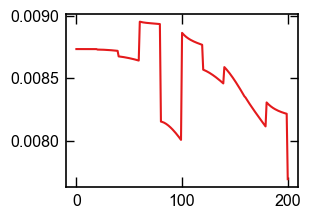

In [47]:
plt.plot(dtrainer.epochs, dtrainer.losses)

In [48]:
idx = np.argmin(dtrainer.losses)
print(dtrainer.epochs[idx], dtrainer.losses[idx])

200 0.0076924497423917606


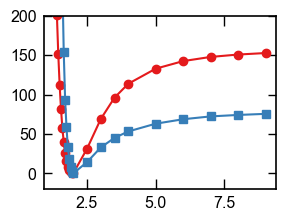

In [49]:
plt.ylim(-20,200)
plt.plot(calculator.qm_scan[0]["distance_A"], np.array(calculator.qm_scan[0]["energy_kjmol"])-min(calculator.qm_scan[0]["energy_kjmol"]), marker="o")
plt.plot(dtrainer.calculator.ff_scan[0]["distance_A"], np.array(dtrainer.calculator.ff_scan[0]["energy_kjmol"])-min(dtrainer.calculator.ff_scan[0]["energy_kjmol"]), marker="s")